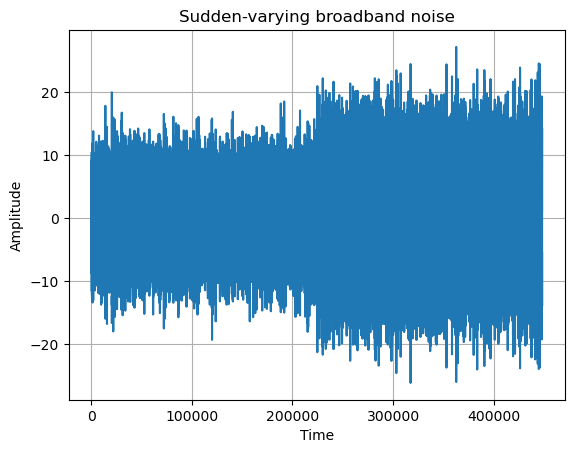

28.0


In [103]:
import matplotlib.pyplot as plt 
from Control_filter_selection import Control_filter_selection
import numpy as np
from scipy import signal
import torch

#-------------------------------------------------------------
def Cascade_broadband_noise(fs, T, f_vector):
    t     = np.arange(0,T,1/fs).reshape(-1,1)
    len_f = 1024
    for ii in range(len(f_vector)):
        b2    = signal.firwin(len_f, f_vector[ii], pass_zero='bandpass', window ='hamming',fs=fs)
        xin   = np.random.randn(len(t))
        Re    = signal.lfilter(b2,1,xin)
        if ii == 0:
            Noise = 20*Re[fs:]
        else:
            Noise = np.concatenate((Noise, 20*Re[fs:]),axis=0)
        
    return torch.from_numpy(Noise).type(torch.float)

F_vector = [[300,700],[1300,2000]] # Broadband noise
fs       = 16000                   # Sampling rate

# Constructing the reference signal 
Broadband_noise = Cascade_broadband_noise(fs=fs, T=15, f_vector=F_vector)

plt.title('Sudden-varying broadband noise')
plt.plot(Broadband_noise.numpy())
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.grid()
plt.show()
print(len(Broadband_noise)/fs)


In [119]:
# Predict control filter index for System 1
id_vector = Control_filter_selection(MODEL_PTH_type=0, fs=16000, Primary_noise=Broadband_noise.unsqueeze(0),Filter_mat_name='BPFs_sys1.mat')
print(id_vector)

torch.Size([15, 1, 16000])
28
The primary nosie has 28 seconds !!!
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [117]:
# Predict control filter index for System 2
id_vector = Control_filter_selection(MODEL_PTH_type=0, fs=16000, Primary_noise=Broadband_noise.unsqueeze(0),Filter_mat_name='BPFs.mat')
print(id_vector)

torch.Size([5, 1, 16000])
28
The primary nosie has 28 seconds !!!
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
